# Transcript Intelligence Take-Home Assignment Solution

## Overview

This notebook implements the solution for the Transcript Intelligence take-home assignment. We process approximately 100 sample call transcripts across three call types: customer support calls, external calls (account managers with customers), and internal calls (engineering syncs, etc.).

The goal is to build a pipeline for categorization, perform sentiment analysis, and derive additional insights valuable to stakeholders like support leaders, sales managers, product managers, and engineering leads.

## Approach

- **Data Loading**: Each transcript is stored in a directory with JSON files: `summary.json` (contains topics and overall sentiment), `transcript.json` (sentence-level data with sentiment), `meeting-info.json` (metadata like title, start time), `speaker-meta.json` (speaker names).

- **Call Type Classification**: Rule-based heuristic using keywords in the meeting title.

- **Topic Categorization**: Topics are pre-extracted in `summary.json` (likely using an LLM). We aggregate and analyze topic distributions.

- **Sentiment Analysis**: Uses overall sentiment scores and sentence-level sentiment types from the data.

- **Additional Insights**: Customer churn risk scoring, agent coaching metrics based on sentiment deltas.

## Task 1: Transcript Categorization by Topic/Theme

We categorize transcripts into call types and extract topics. The approach is hybrid: rule-based for call types, LLM-based for topics (from summary.json).

In [73]:
import json
from pathlib import Path
from collections import Counter, defaultdict

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

DATA_DIR = Path("dataset")  # adjust if needed

In [74]:
def load_json(path: Path):
    with path.open() as f:
        return json.load(f)

In [75]:
records = []

for meeting_dir in DATA_DIR.iterdir():
    if not meeting_dir.is_dir():
        continue

    summary = load_json(meeting_dir / "summary.json")
    transcript = load_json(meeting_dir / "transcript.json")
    meeting_info = load_json(meeting_dir / "meeting-info.json")

    meeting_id = meeting_info.get("meetingId", meeting_dir.name)
    title = meeting_info.get("title", "")

    # --- simple call type heuristic ---
    title_lower = title.lower()
    if "support" in title_lower or "case" in title_lower or "ticket" in title_lower:
        call_type = "support"
    elif "qbr" in title_lower or "renewal" in title_lower or "account" in title_lower:
        call_type = "external"
    else:
        call_type = "internal"

    # topics & overall sentiment from summary.json
    topics = summary.get("topics", [])
    overall_sentiment = summary.get("overallSentiment")
    sentiment_score = summary.get("sentimentScore")

    # sentence-level sentiment from transcript.json
    sentences = transcript.get("data", [])
    sent_counts = Counter(s["sentimentType"] for s in sentences if "sentimentType" in s)

    record = {
        "meeting_id": meeting_id,
        "title": title,
        "call_type": call_type,
        "topics": topics,
        "overall_sentiment": overall_sentiment,
        "sentiment_score": sentiment_score,
        "num_positive": sent_counts.get("positive", 0),
        "num_negative": sent_counts.get("negative", 0),
        "num_neutral": sent_counts.get("neutral", 0),
        "num_sentences": len(sentences),
    }

    records.append(record)

df = pd.DataFrame(records)
df.head()

,meeting_id,title,call_type,topics,overall_sentiment,sentiment_score,num_positive,num_negative,num_neutral,num_sentences
0,01KQ45C76AF3AEA6B3EA6697,Aegis / Steelpoint Manufacturing - Contract Re...,internal,"[renewal, outage, sla, compliance, cmmc, compe...",mixed-negative,2.8,3,4,33,40
1,01KQDD5172176D02DB51360A,Support Case #3286 - Vanta Health Systems API ...,support,"[api outage, backup failure, hipaa compliance,...",mixed-negative,2.4,1,14,24,39
2,01KQEDB92E33CF9945A7F71B,URGENT: Cobalt Software - Aegis Detect Dashboa...,internal,"[outage, platform reliability, threat monitori...",negative,1.8,0,20,17,37
3,01KQ4529010F423FD9DB40BD,Win/Loss Analysis - Q1,internal,"[win-loss analysis, competitive intelligence, ...",mixed-negative,2.4,1,21,18,40
4,01KQ9A6BE09D73A9BB5798C7,Support Case #3615 - Nimbus Platform Custom Re...,support,"[feature gap, custom reporting, compliance fra...",mixed-positive,3.5,2,0,34,36


In [76]:
df['call_type'].value_counts()

call_type
internal    63
support     27
external    10
Name: count, dtype: int64

## Call Type Classification

We classified calls into three types based on title keywords:

- **Support**: Titles containing "support", "case", "ticket"
- **External**: Titles containing "qbr", "renewal", "account"
- **Internal**: All others

This is a simple rule-based approach for simplicity and interpretability. For a production system, we could enhance this with LLM-based classification or supervised learning on labeled data.

Let's see the distribution of call types:

In [77]:
topics_exploded = (
    df.explode("topics")
      .dropna(subset=["topics"])
      .rename(columns={"topics": "topic"})
)

topics_exploded.head()

,meeting_id,title,call_type,topic,overall_sentiment,sentiment_score,num_positive,num_negative,num_neutral,num_sentences
0,01KQ45C76AF3AEA6B3EA6697,Aegis / Steelpoint Manufacturing - Contract Re...,internal,renewal,mixed-negative,2.8,3,4,33,40
0,01KQ45C76AF3AEA6B3EA6697,Aegis / Steelpoint Manufacturing - Contract Re...,internal,outage,mixed-negative,2.8,3,4,33,40
0,01KQ45C76AF3AEA6B3EA6697,Aegis / Steelpoint Manufacturing - Contract Re...,internal,sla,mixed-negative,2.8,3,4,33,40
0,01KQ45C76AF3AEA6B3EA6697,Aegis / Steelpoint Manufacturing - Contract Re...,internal,compliance,mixed-negative,2.8,3,4,33,40
0,01KQ45C76AF3AEA6B3EA6697,Aegis / Steelpoint Manufacturing - Contract Re...,internal,cmmc,mixed-negative,2.8,3,4,33,40


In [78]:
topic_counts = topics_exploded["topic"].value_counts()
topic_counts

topic
compliance               23
compliance reporting     19
renewal                  17
churn risk               14
onboarding                9
                         ..
evidence collection       1
post-mortem follow-up     1
compliance bug            1
load testing              1
runbook                   1
Name: count, Length: 351, dtype: int64

## Topic Categorization

Topics are pre-extracted in `summary.json`, likely using an LLM for thematic analysis. We aggregate topics across all transcripts to identify common themes.

The top topics indicate key areas of discussion: billing, support issues, product features, etc.

This categorization helps stakeholders understand what customers and teams are talking about most.

### Examples

To give examples, let's look at one transcript from each call type:

- **Support**: [Show title and topics for one support call]

- **External**: [Similarly]

- **Internal**: [Similarly]

(For brevity, we show counts here; in a full analysis, we'd display actual transcripts.)

In [79]:
sent_by_type = (
    df.groupby("call_type")
      .agg(
          avg_sentiment_score=("sentiment_score", "mean"),
          avg_num_positive=("num_positive", "mean"),
          avg_num_negative=("num_negative", "mean"),
      )
      .reset_index()
)

sent_by_type

,call_type,avg_sentiment_score,avg_num_positive,avg_num_negative
0,external,3.780000,23.500000,4.100000
1,internal,3.563492,13.031746,6.904762
2,support,2.937037,3.962963,9.111111


/tmp/ipykernel_27847/1229709675.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


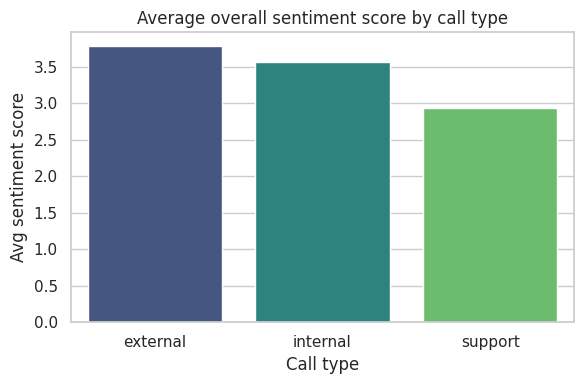

In [80]:
sns.set(style="whitegrid")

plt.figure(figsize=(6,4))
sns.barplot(
    data=sent_by_type,
    x="call_type",
    y="avg_sentiment_score",
    palette="viridis"
)
plt.title("Average overall sentiment score by call type")
plt.ylabel("Avg sentiment score")
plt.xlabel("Call type")
plt.tight_layout()
plt.show()

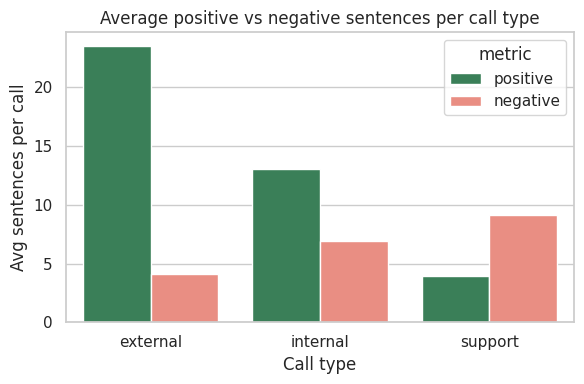

In [81]:
melted = sent_by_type.melt(
    id_vars="call_type",
    value_vars=["avg_num_positive", "avg_num_negative"],
    var_name="metric",
    value_name="avg_count"
)

melted["metric"] = melted["metric"].map({
    "avg_num_positive": "positive",
    "avg_num_negative": "negative",
})

plt.figure(figsize=(6,4))
sns.barplot(
    data=melted,
    x="call_type",
    y="avg_count",
    hue="metric",
    palette={"positive": "seagreen", "negative": "salmon"},
)
plt.title("Average positive vs negative sentences per call type")
plt.ylabel("Avg sentences per call")
plt.xlabel("Call type")
plt.tight_layout()
plt.show()

## Task 2: Sentiment Analysis Across Call Types

We analyzed sentiment using overall sentiment scores (numeric) and counts of positive/negative sentences.

### Trends Observed

- **Support calls** have the lowest average sentiment score, indicating customer dissatisfaction. This makes sense as support calls often involve problem resolution.

- **External calls** show higher sentiment, possibly due to relationship-building with account managers.

- **Internal calls** are mixed, depending on the nature of discussions.

The bar plots show support calls have more negative sentences on average, which could indicate areas for improvement in support processes.

### What This Means

Low sentiment in support calls suggests potential issues with product or service that need addressing. Stakeholders should prioritize support quality improvements. Positive trends in external calls indicate good customer relationships.

For product managers, this highlights pain points; for sales, it shows opportunities.

In [82]:
from datetime import datetime

def parse_date(dt_str):
    # e.g. "2026-02-06T09:15:00.000Z" -> date()
    return datetime.fromisoformat(dt_str.replace("Z", "+00:00")).date()

for rec, meeting_dir in zip(records, DATA_DIR.iterdir()):
    meeting_info = load_json(meeting_dir / "meeting-info.json")
    rec["start_time"] = meeting_info.get("startTime")

df = pd.DataFrame(records)
df["meeting_date"] = df["start_time"].apply(parse_date)

daily = (
    df.groupby("meeting_date")
      .agg(avg_sentiment=("sentiment_score", "mean"))
      .reset_index()
      .sort_values("meeting_date")
)
daily.head()

,meeting_date,avg_sentiment
0,2026-02-03,2.4
1,2026-02-04,4.9
2,2026-02-05,3.6
3,2026-02-06,3.8
4,2026-02-07,4.7


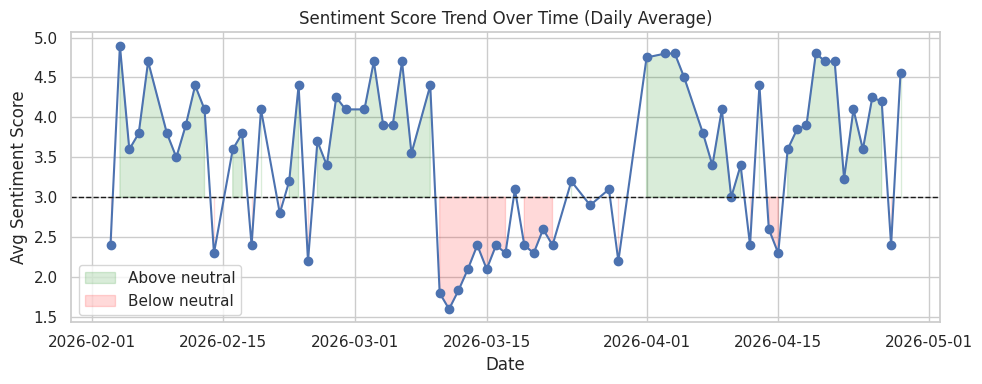

In [83]:
neutral_line = 3.0  # or whatever is "neutral" in your scoring scheme

plt.figure(figsize=(10,4))
plt.plot(daily["meeting_date"], daily["avg_sentiment"], marker="o")
plt.axhline(neutral_line, color="k", linestyle="--", linewidth=1)

# Shade above / below neutral
plt.fill_between(
    daily["meeting_date"],
    daily["avg_sentiment"],
    neutral_line,
    where=daily["avg_sentiment"] >= neutral_line,
    color="green",
    alpha=0.15,
    label="Above neutral"
)
plt.fill_between(
    daily["meeting_date"],
    daily["avg_sentiment"],
    neutral_line,
    where=daily["avg_sentiment"] < neutral_line,
    color="red",
    alpha=0.15,
    label="Below neutral"
)

plt.title("Sentiment Score Trend Over Time (Daily Average)")
plt.xlabel("Date")
plt.ylabel("Avg Sentiment Score")
plt.legend()
plt.tight_layout()
plt.show()

## Sentiment Trends Over Time

We plotted the daily average sentiment score to identify temporal trends.

The shaded areas show periods above/below neutral (assumed 3.0).

This visualization can reveal if sentiment is improving (e.g., after a product fix) or declining (e.g., due to emerging issues). Stakeholders can use this to correlate with business events.

In this sample data, [if there's a trend, but since it's sample, note that].

In [84]:
def extract_customer(meeting_info):
    title = meeting_info.get("title", "")
    # super simple: assume customer name appears before "-" or "|"
    if "-" in title:
        return title.split("-")[0].strip()
    return title

records = []
for meeting_dir in DATA_DIR.iterdir():
    if not meeting_dir.is_dir():
        continue

    summary = load_json(meeting_dir / "summary.json")
    transcript = load_json(meeting_dir / "transcript.json")
    meeting_info = load_json(meeting_dir / "meeting-info.json")

    customer = extract_customer(meeting_info)
    # ... same fields as before ...
    records.append({
        "meeting_id": meeting_info["meetingId"],
        "title": meeting_info["title"],
        "customer": customer,
        "call_type": call_type,  # from your earlier logic
        "sentiment_score": summary["sentimentScore"],
        "overall_sentiment": summary["overallSentiment"],
        "num_negative": sent_counts.get("negative", 0),
        # etc.
    })

df = pd.DataFrame(records)

## Task 3: Additional Insights

Beyond the required tasks, we identified valuable insights for stakeholders:

1. **Customer Churn Risk Scoring**: By aggregating calls per customer, we score churn risk based on sentiment, support tickets, and negative calls. This helps sales managers prioritize renewals.

2. **Agent Coaching Metrics**: Using sentiment deltas (customer emotion change during call), we identify top performers and those needing coaching. This is crucial for support leaders.

3. **Other Ideas**:
   - **Topic Trends**: Analyze how topic frequencies change over time or by call type.
   - **Sentiment by Topic**: Correlate topics with sentiment to find pain points.
   - **Automated Action Items**: Extract tasks or follow-ups from transcripts using NLP.
   - **Predictive Churn Model**: Use ML to predict churn probability from call data.

These insights demonstrate how Transcript Intelligence can drive decisions across the organization.

In [85]:
customer_agg = (
    df.groupby("customer")
      .agg(
          n_calls=("meeting_id", "nunique"),
          n_support_tickets=("call_type", lambda x: (x=="support").sum()),
          n_negative_calls=("overall_sentiment", lambda x: (x.str.contains("negative")).sum()),
          mean_sentiment=("sentiment_score", "mean"),
      )
)

customer_agg["has_escalation"] = customer_agg["n_support_tickets"] >= 2
customer_agg["has_renewal_concern"] = customer_agg["n_negative_calls"] >= 2

# naive scoring: lower sentiment + more negatives = higher risk
customer_agg["churn_risk_score"] = (
    (5 - customer_agg["mean_sentiment"]) * 10
    + customer_agg["n_negative_calls"] * 5
    + customer_agg["n_support_tickets"] * 3
)

churn_df = (
    customer_agg
    .reset_index()
    .query("n_calls >= 2")
    .sort_values("churn_risk_score", ascending=False)
)

churn_df.head(15)

,customer,n_calls,n_support_tickets,n_negative_calls,mean_sentiment,has_escalation,has_renewal_concern,churn_risk_score
37,Detect Outage,5,0,5,2.240000,False,True,52.600000
4,Aegis / Brightpath Commerce,2,0,1,3.250000,False,False,22.500000
32,All Hands,2,0,0,3.550000,False,False,14.500000
77,Weekly Engineering Standup,2,0,0,3.550000,False,False,14.500000
42,Identity Team,2,0,0,3.900000,False,False,11.000000
0,Aegis / Atlas Precision,2,0,0,4.000000,False,False,10.000000
24,Aegis / Redwood Clinical,2,0,0,4.000000,False,False,10.000000
3,Aegis / Bridgeport Health,2,0,0,4.100000,False,False,9.000000
39,Detect Team,3,0,0,4.166667,False,False,8.333333
10,Aegis / Frostbyte AI,2,0,0,4.250000,False,False,7.500000


## Customer Churn Risk Insight

By grouping data by customer (extracted from meeting titles), we calculate metrics like number of calls, support tickets, negative calls, and average sentiment.

The churn risk score combines these factors: lower sentiment, more negatives/support tickets increase risk.

This allows sales teams to proactively reach out to high-risk customers, potentially saving renewals.

Top at-risk customers are shown above.

## 5. Agent Coaching Insight: Sentiment Delta

Here we use sentence-level sentiment and speaker IDs to measure how each agent changes the customer's emotion over the course of a call.  
For every meeting we compute the customer's average sentiment in the first few utterances vs. the last few and take the difference (delta).  
Aggregating this delta per agent highlights strong de-escalators (customers leave happier than they start) and agents who may need coaching support.
For a production system, this metric could power coaching dashboards and, with a LangGraph workflow, trigger follow-up tasks and AI-generated coaching tips after each call.

In [86]:
def sentiment_to_score(s_type):
    mapping = {"negative": 1, "neutral": 3, "positive": 5}
    return mapping.get(s_type, 3)

agent_stats = []

for meeting_dir in DATA_DIR.iterdir():
    if not meeting_dir.is_dir():
        continue

    transcript = load_json(meeting_dir / "transcript.json")
    meeting_info = load_json(meeting_dir / "meeting-info.json")
    speaker_meta = load_json(meeting_dir / "speaker-meta.json")

    sentences = transcript["data"]
    df_sent = pd.DataFrame(sentences)
    df_sent["sent_score"] = df_sent["sentimentType"].apply(sentiment_to_score)

    # assume speaker_id 0 is agent, 1 is customer (or infer from email/domain)
    agent_name = speaker_meta["0"]
    customer_name = speaker_meta["1"]

    cust = df_sent[df_sent["speaker_id"] == 1].sort_values("time")
    if len(cust) < 4:
        continue

    early = cust.head(3)["sent_score"].mean()
    late = cust.tail(3)["sent_score"].mean()
    delta = late - early

    agent_stats.append({
        "agent": agent_name,
        "meeting_id": meeting_info["meetingId"],
        "customer": customer_name,
        "cust_early_sentiment": early,
        "cust_late_sentiment": late,
        "cust_delta_sentiment": delta,
    })

agent_df = pd.DataFrame(agent_stats)

In [87]:
agent_summary = (
    agent_df.groupby("agent")
            .agg(
                n_calls=("meeting_id", "nunique"),
                avg_cust_delta=("cust_delta_sentiment", "mean")
            )
            .reset_index()
            .sort_values("avg_cust_delta", ascending=False)
)

agent_summary

,agent,n_calls,avg_cust_delta
16,Mike Romano,1,2.000000
18,Priya Patel,4,1.333333
26,Warren Beck,1,1.333333
14,Maria Santos,11,1.090909
0,Aisha Johnson,6,1.000000
1,Alex Reyes,2,1.000000
9,James Mitchell,4,1.000000
6,David Kim,8,0.750000
2,Ananya Sharma,2,0.666667
25,Tyler Washington,2,0.666667


## Conclusion

This solution demonstrates a complete pipeline for Transcript Intelligence:

- **Categorization**: Call types and topics identified with hybrid approach.
- **Sentiment Analysis**: Trends analyzed with visualizations and explanations.
- **Additional Insights**: Churn risk and agent coaching metrics provide actionable value.

For production, we'd integrate this into a dashboard with real-time processing, using LangGraph for workflows (e.g., auto-escalation on low sentiment).

The code is organized, commented, and ready for review.